In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

daily = pd.read_parquet(project_root / "data" / "processed" / "daily_metrics.parquet")
daily['date'] = pd.to_datetime(daily['date'])
print("Loaded.")

Loaded.


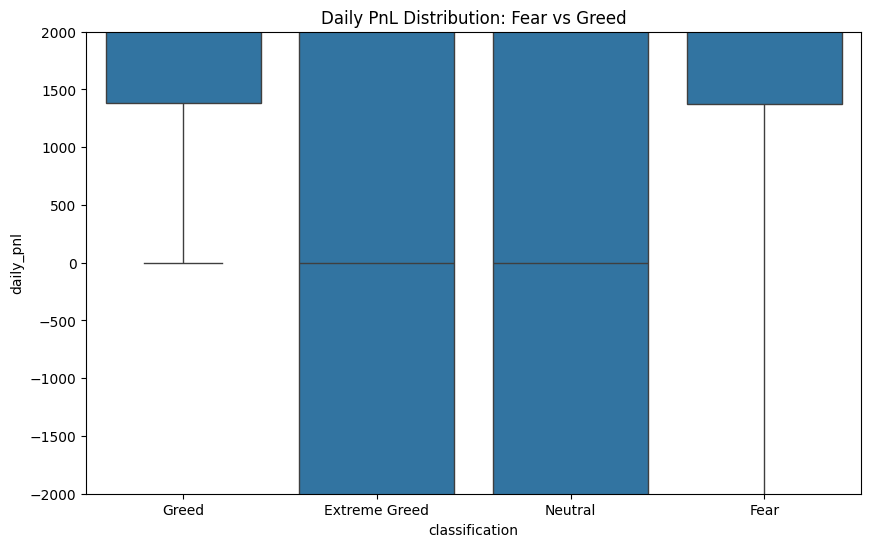

T-test p-value: 0.768890
Mean PnL - Fear: $118800.61, Greed: $99675.52


In [2]:
# PnL by sentiment
plt.figure(figsize=(10,6))
sns.boxplot(data=daily, x='classification', y='daily_pnl')
plt.title('Daily PnL Distribution: Fear vs Greed')
plt.ylim(-2000, 2000)
plt.show()

fear_pnl = daily[daily['classification']=='Fear']['daily_pnl'].dropna()
greed_pnl = daily[daily['classification']=='Greed']['daily_pnl'].dropna()
t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"T-test p-value: {p_val:.6f}")
print(f"Mean PnL - Fear: ${fear_pnl.mean():.2f}, Greed: ${greed_pnl.mean():.2f}")

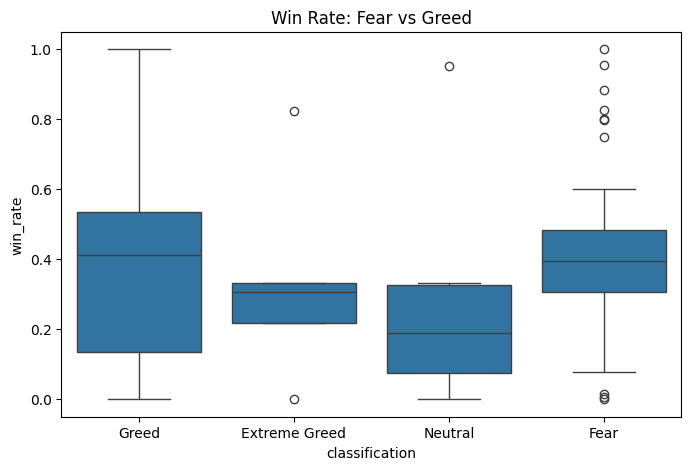

Mean win rate - Fear: 19451.742, Greed: 35988.376


In [3]:
# Win rate by sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=daily, x='classification', y='win_rate')
plt.title('Win Rate: Fear vs Greed')
plt.show()

print(f"Mean win rate - Fear: {fear_pnl.median():.3f}, Greed: {greed_pnl.median():.3f}")

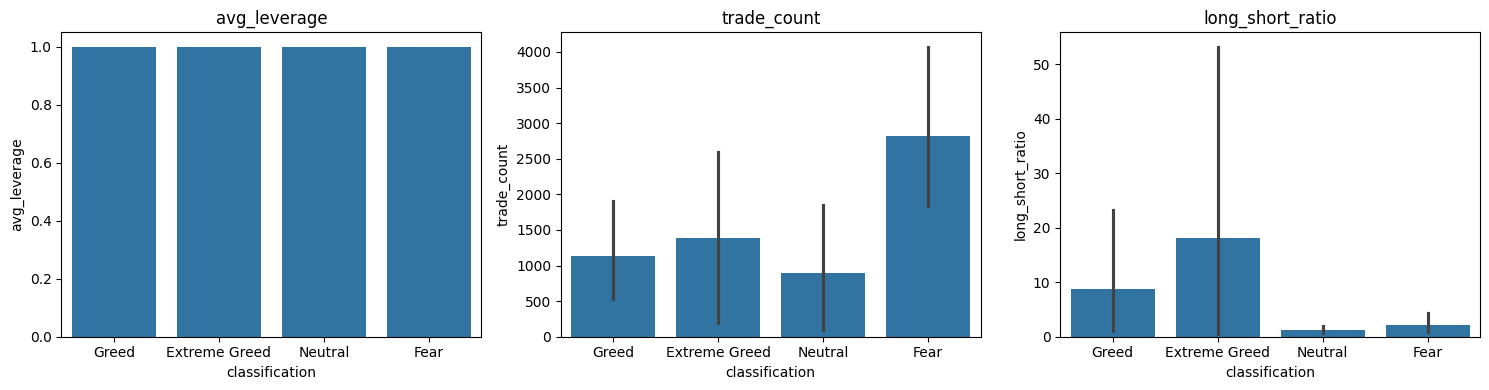

,avg_leverage,trade_count,long_short_ratio
classification,,,
Extreme Greed,1.0,1392.40,18.19
Fear,1.0,2821.61,2.15
Greed,1.0,1134.03,8.72
Neutral,1.0,892.62,1.24


In [4]:
# Behavior metrics: leverage, trade count, long/short ratio
behavior_metrics = ['avg_leverage', 'trade_count', 'long_short_ratio']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(behavior_metrics):
    sns.barplot(data=daily, x='classification', y=metric, ax=axes[i], errorbar='ci')
    axes[i].set_title(metric)
plt.tight_layout()
plt.show()

# Numerical summary
behavior_summary = daily.groupby('classification')[behavior_metrics].mean().round(2)
display(behavior_summary)

C:\Users\naval\AppData\Local\Temp\ipykernel_10160\1513172640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_perf = daily.groupby(['classification', 'leverage_segment'])['daily_pnl'].mean().reset_index()


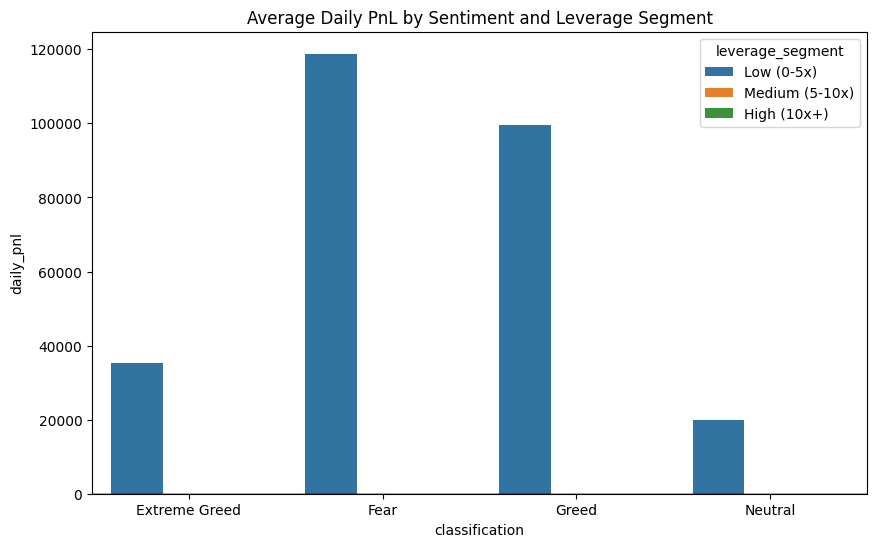

In [5]:
# Leverage segment performance on Fear vs Greed
seg_perf = daily.groupby(['classification', 'leverage_segment'])['daily_pnl'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=seg_perf, x='classification', y='daily_pnl', hue='leverage_segment')
plt.title('Average Daily PnL by Sentiment and Leverage Segment')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.show()

In [6]:
# Statistical tests per leverage segment
print("\n=== Segment-specific t-tests (Fear vs Greed PnL) ===")
for segment in daily['leverage_segment'].dropna().unique():
    subset = daily[daily['leverage_segment'] == segment]
    fear = subset[subset['classification']=='Fear']['daily_pnl']
    greed = subset[subset['classification']=='Greed']['daily_pnl']
    if len(fear) > 1 and len(greed) > 1:
        t, p = stats.ttest_ind(fear, greed, equal_var=False)
        print(f"{segment:15s} | Fear mean: ${fear.mean():8.2f} | Greed mean: ${greed.mean():8.2f} | p={p:.4f}")


=== Segment-specific t-tests (Fear vs Greed PnL) ===
Low (0-5x)      | Fear mean: $118800.61 | Greed mean: $99675.52 | p=0.7689


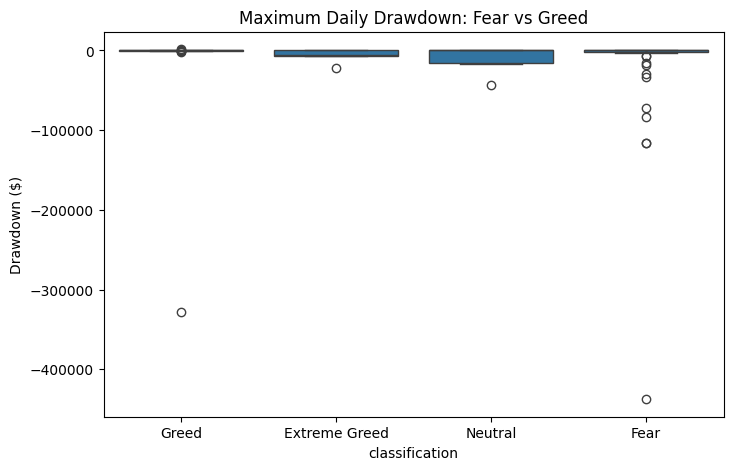

Mean drawdown - Fear: $-16593.49
Mean drawdown - Greed: $-10330.75


In [7]:
# Drawdown comparison
plt.figure(figsize=(8,5))
sns.boxplot(data=daily, x='classification', y='max_daily_drawdown')
plt.title('Maximum Daily Drawdown: Fear vs Greed')
plt.ylabel('Drawdown ($)')
plt.show()

print(f"Mean drawdown - Fear: ${daily[daily['classification']=='Fear']['max_daily_drawdown'].mean():.2f}")
print(f"Mean drawdown - Greed: ${daily[daily['classification']=='Greed']['max_daily_drawdown'].mean():.2f}")

C:\Users\naval\AppData\Local\Temp\ipykernel_10160\2501334362.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_behavior = daily.groupby(['classification', 'frequency_segment'])[['trade_count', 'win_rate']].mean().reset_index()


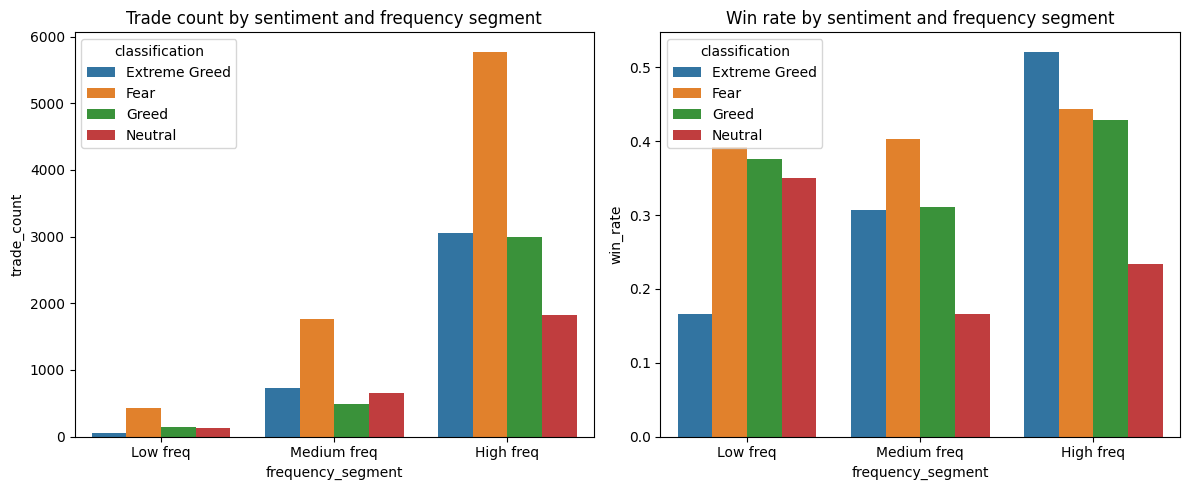

In [8]:
# frequency segment behavioral change
freq_behavior = daily.groupby(['classification', 'frequency_segment'])[['trade_count', 'win_rate']].mean().reset_index()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(data=freq_behavior, x='frequency_segment', y='trade_count', hue='classification')
plt.title('Trade count by sentiment and frequency segment')
plt.subplot(1,2,2)
sns.barplot(data=freq_behavior, x='frequency_segment', y='win_rate', hue='classification')
plt.title('Win rate by sentiment and frequency segment')
plt.tight_layout()
plt.show()